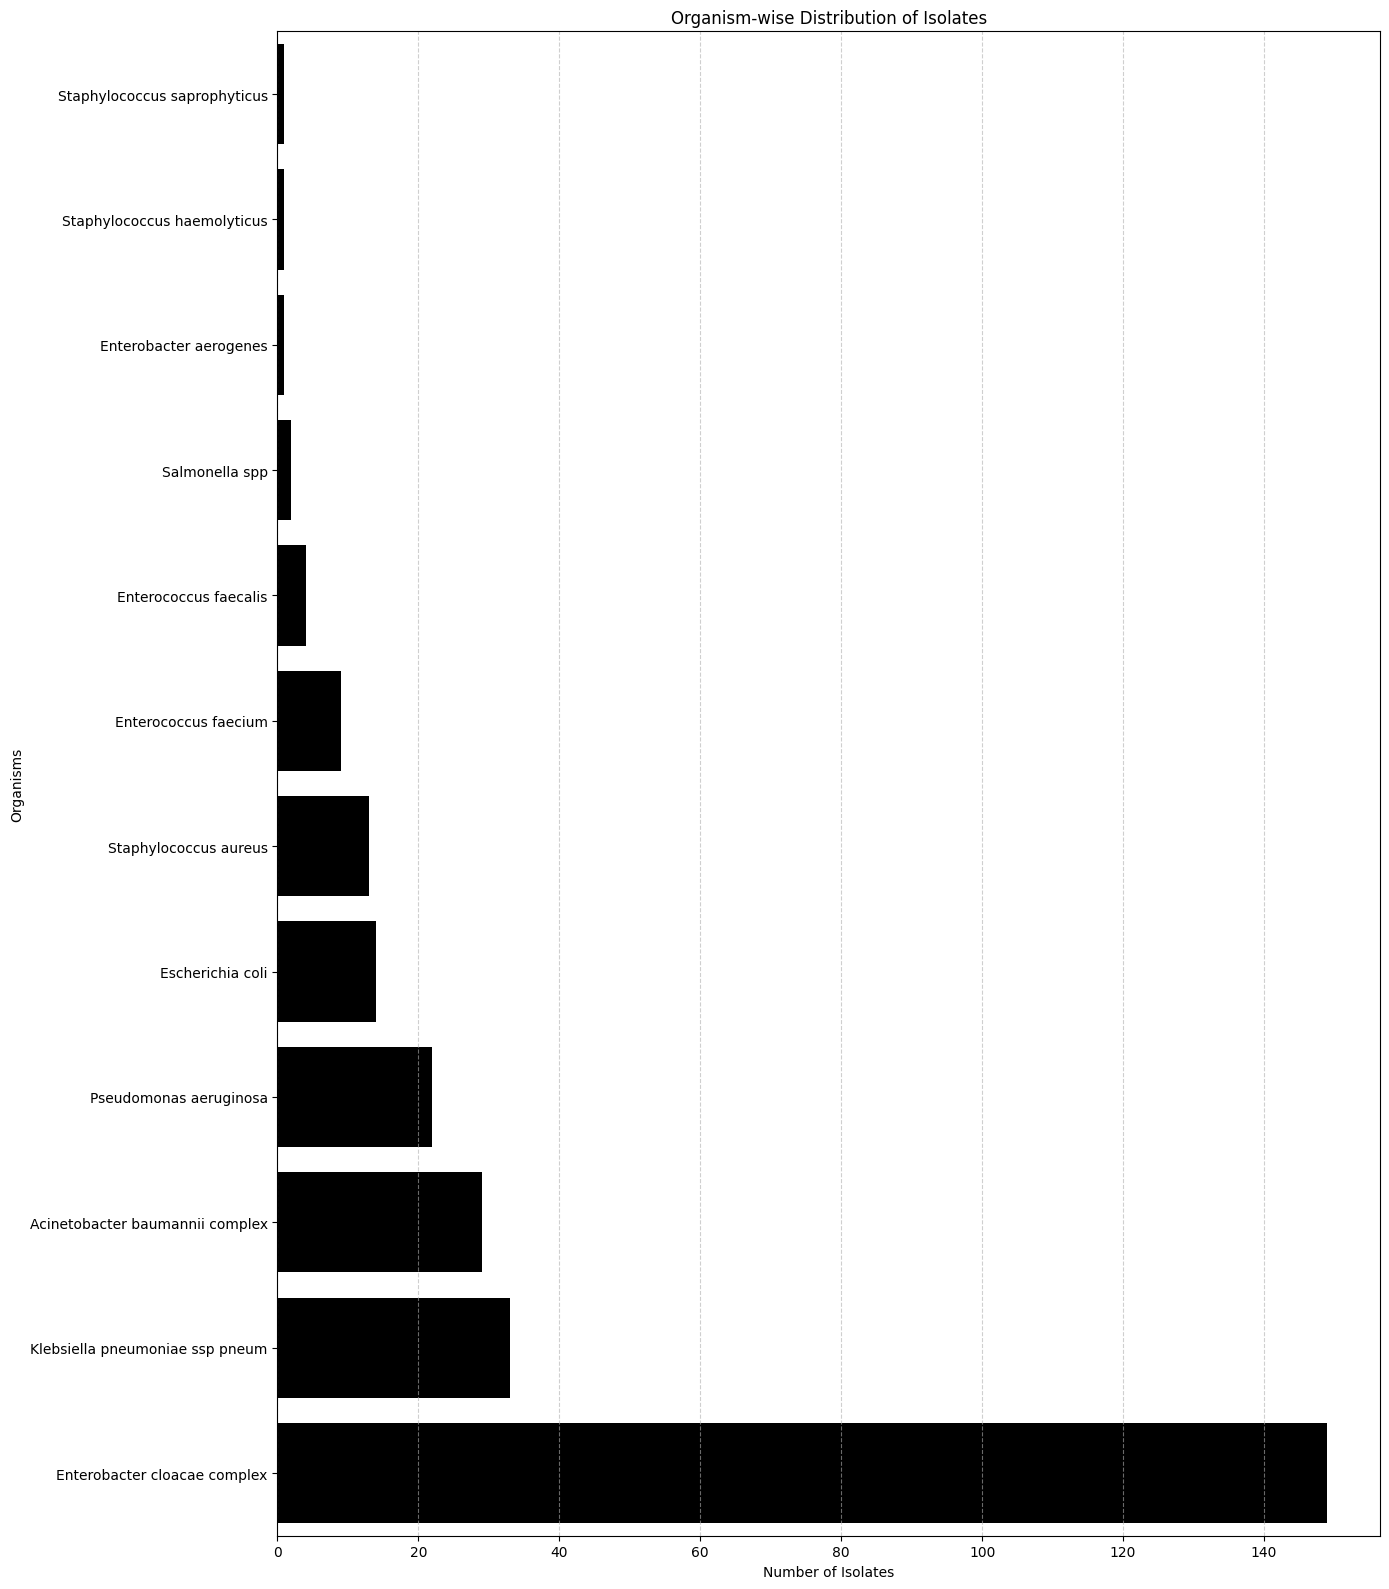

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')

# Count how many isolates per organism
organism_counts = df['Bacteria'].value_counts().sort_values(ascending=True)

# Plot (horizontal bar chart)
plt.figure(figsize=(14,16))
sns.barplot(x=organism_counts.values, y=organism_counts.index, color='black')
plt.title("Organism-wise Distribution of Isolates")
plt.xlabel("Number of Isolates")
plt.ylabel("Organisms")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("C:Documents/Organism-wise_Distribution_of_Isolates.png", dpi=300, bbox_inches='tight')
plt.show()



Decision Tree for Amoxicillin trained and saved to 'decision_tree_ciprofloxacin_resistance.png'
Class Mapping (Predicted Class): {np.int64(0): 'R', np.int64(1): 'S'}


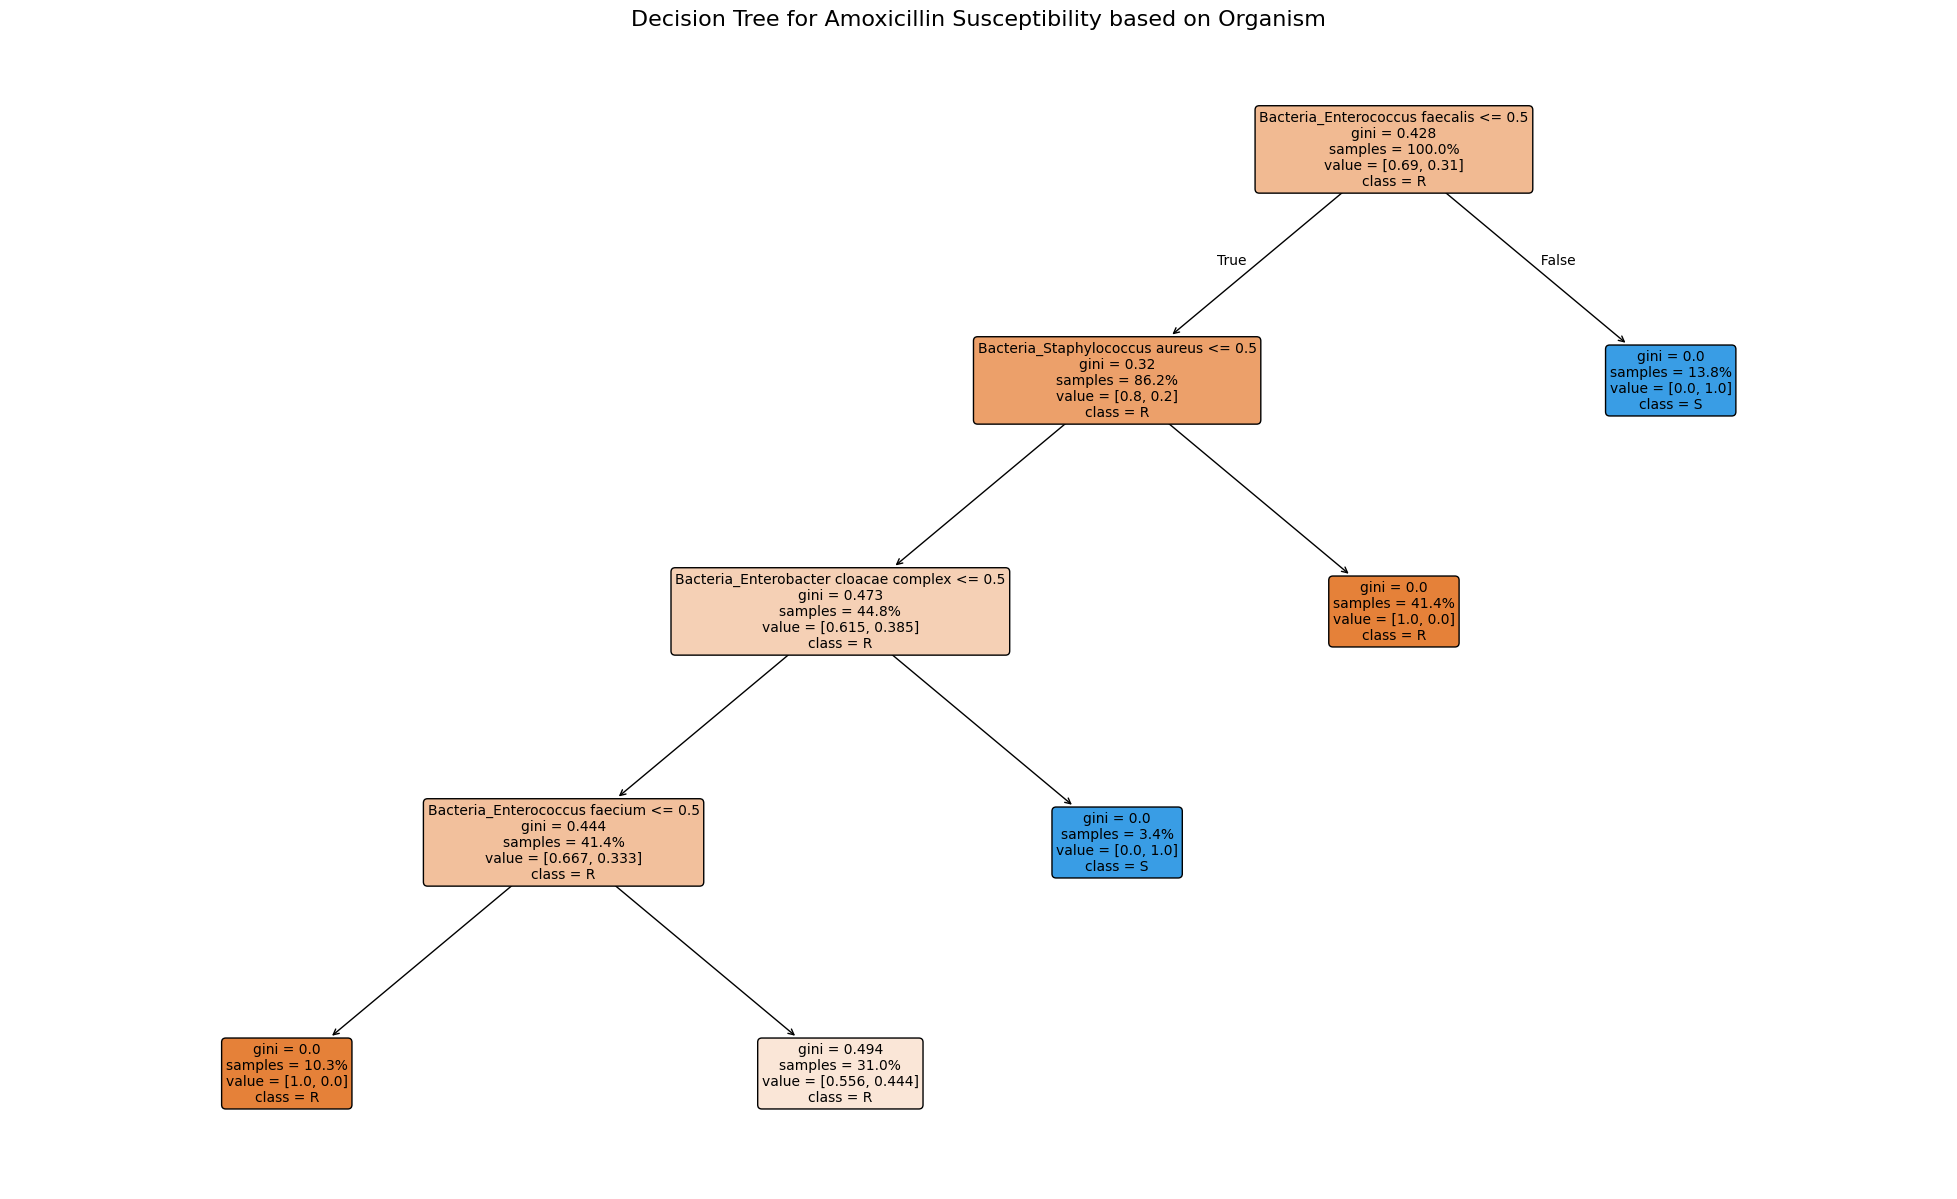

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# --- Configuration ---
TARGET_ANTIBIOTIC = 'Amoxicillin'
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')

# 2. Data Cleaning and Preparation
# Clean up column names (remove newlines, replace spaces/slashes/parentheses with underscore)
df.columns = df.columns.str.replace(r'[\n\r]+', ' ', regex=True)
df.columns = df.columns.str.replace(r'[ /()]', '_', regex=True).str.replace('__', '_', regex=False).str.strip('_')

# Identify the target column dynamically after cleaning
target_col_search = TARGET_ANTIBIOTIC.replace(' ', '_').replace('/', '_')
cipro_cols = [col for col in df.columns if target_col_search in col]

if not cipro_cols:
    print(f"Error: Could not find a suitable column for {TARGET_ANTIBIOTIC}.")
    print(f"Available columns: {df.columns.tolist()}")
    exit()

target_col_clean = cipro_cols[0]

y = df[target_col_clean].copy()
X = df[['Bacteria']].copy()

# Remove rows where the target result is not standard (R, S, I)
valid_results = ['R', 'S', 'I']
df_clean = df[y.isin(valid_results)].copy()
X = df_clean[['Bacteria']]
y = df_clean[target_col_clean]

# Encode the categorical target variable (y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_ # R, S, I

# One-hot encode the 'Bacteria' feature
X_encoded = pd.get_dummies(X, columns=['Bacteria'], prefix='Bacteria')

# 3. Train the Decision Tree Model
# Using the entire cleaned dataset for a representative model of the dataset structure
model = DecisionTreeClassifier(max_depth=4, random_state=42) # Max depth limited for clear visualization
model.fit(X_encoded, y_encoded)

# 4. Plot and Save the Decision Tree
feature_names = X_encoded.columns.tolist()

# Prepare class names for the plot based on the LabelEncoder mapping
# 0: I, 1: R, 2: S (or whatever the alphabetical order is for the classes)
class_map = {val: name for val, name in zip(le.transform(le.classes_), le.classes_)}
class_names_for_plot = [f"{class_map[i]}" for i in sorted(class_map.keys())]

plt.figure(figsize=(25, 15))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names_for_plot,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10
)
plt.title(f"Decision Tree for {TARGET_ANTIBIOTIC} Susceptibility based on Organism", fontsize=16)

# Save the plot
plt.savefig("decision_tree_ciprofloxacin_resistance.png")

print(f"Decision Tree for {TARGET_ANTIBIOTIC} trained and saved to 'decision_tree_ciprofloxacin_resistance.png'")
print(f"Class Mapping (Predicted Class): {class_map}")

Decision Tree for Amikacin trained and saved to 'decision_tree_ciprofloxacin_resistance.png'
Class Mapping (Predicted Class): {np.int64(0): 'R', np.int64(1): 'S'}


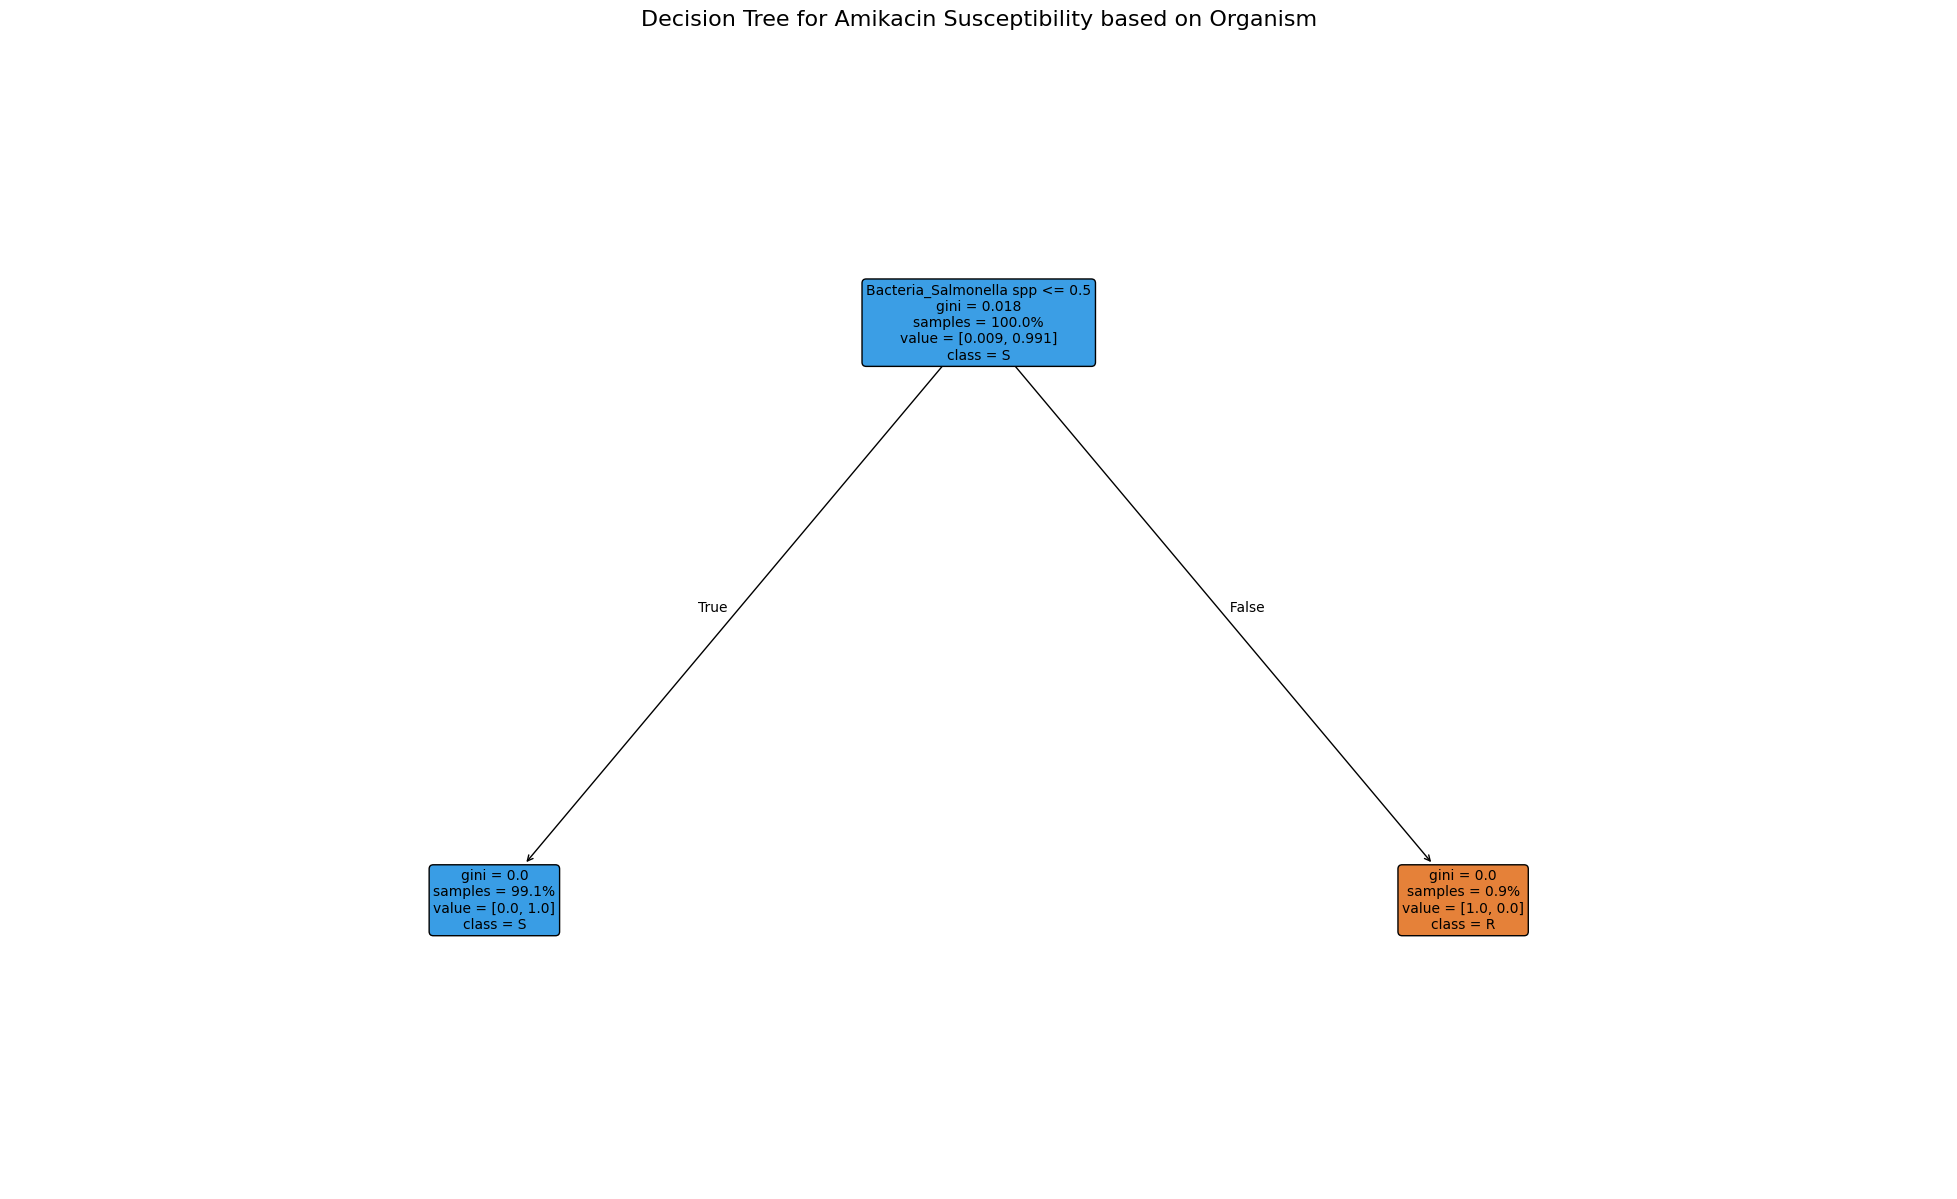

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# --- Configuration ---
TARGET_ANTIBIOTIC = 'Amikacin'
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')

# 2. Data Cleaning and Preparation
# Clean up column names (remove newlines, replace spaces/slashes/parentheses with underscore)
df.columns = df.columns.str.replace(r'[\n\r]+', ' ', regex=True)
df.columns = df.columns.str.replace(r'[ /()]', '_', regex=True).str.replace('__', '_', regex=False).str.strip('_')

# Identify the target column dynamically after cleaning
target_col_search = TARGET_ANTIBIOTIC.replace(' ', '_').replace('/', '_')
cipro_cols = [col for col in df.columns if target_col_search in col]

if not cipro_cols:
    print(f"Error: Could not find a suitable column for {TARGET_ANTIBIOTIC}.")
    print(f"Available columns: {df.columns.tolist()}")
    exit()

target_col_clean = cipro_cols[0]

y = df[target_col_clean].copy()
X = df[['Bacteria']].copy()

# Remove rows where the target result is not standard (R, S, I)
valid_results = ['R', 'S', 'I']
df_clean = df[y.isin(valid_results)].copy()
X = df_clean[['Bacteria']]
y = df_clean[target_col_clean]

# Encode the categorical target variable (y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_ # R, S, I

# One-hot encode the 'Bacteria' feature
X_encoded = pd.get_dummies(X, columns=['Bacteria'], prefix='Bacteria')

# 3. Train the Decision Tree Model
# Using the entire cleaned dataset for a representative model of the dataset structure
model = DecisionTreeClassifier(max_depth=4, random_state=42) # Max depth limited for clear visualization
model.fit(X_encoded, y_encoded)

# 4. Plot and Save the Decision Tree
feature_names = X_encoded.columns.tolist()

# Prepare class names for the plot based on the LabelEncoder mapping
# 0: I, 1: R, 2: S (or whatever the alphabetical order is for the classes)
class_map = {val: name for val, name in zip(le.transform(le.classes_), le.classes_)}
class_names_for_plot = [f"{class_map[i]}" for i in sorted(class_map.keys())]

plt.figure(figsize=(25, 15))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names_for_plot,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10
)
plt.title(f"Decision Tree for {TARGET_ANTIBIOTIC} Susceptibility based on Organism", fontsize=16)

# Save the plot
plt.savefig("decision_tree_amikacin_resistance.png")

print(f"Decision Tree for {TARGET_ANTIBIOTIC} trained and saved to 'decision_tree_ciprofloxacin_resistance.png'")
print(f"Class Mapping (Predicted Class): {class_map}")

Decision Tree for Cefalotin trained and saved to 'decision_tree_ciprofloxacin_resistance.png'
Class Mapping (Predicted Class): {np.int64(0): 'I', np.int64(1): 'R', np.int64(2): 'S'}


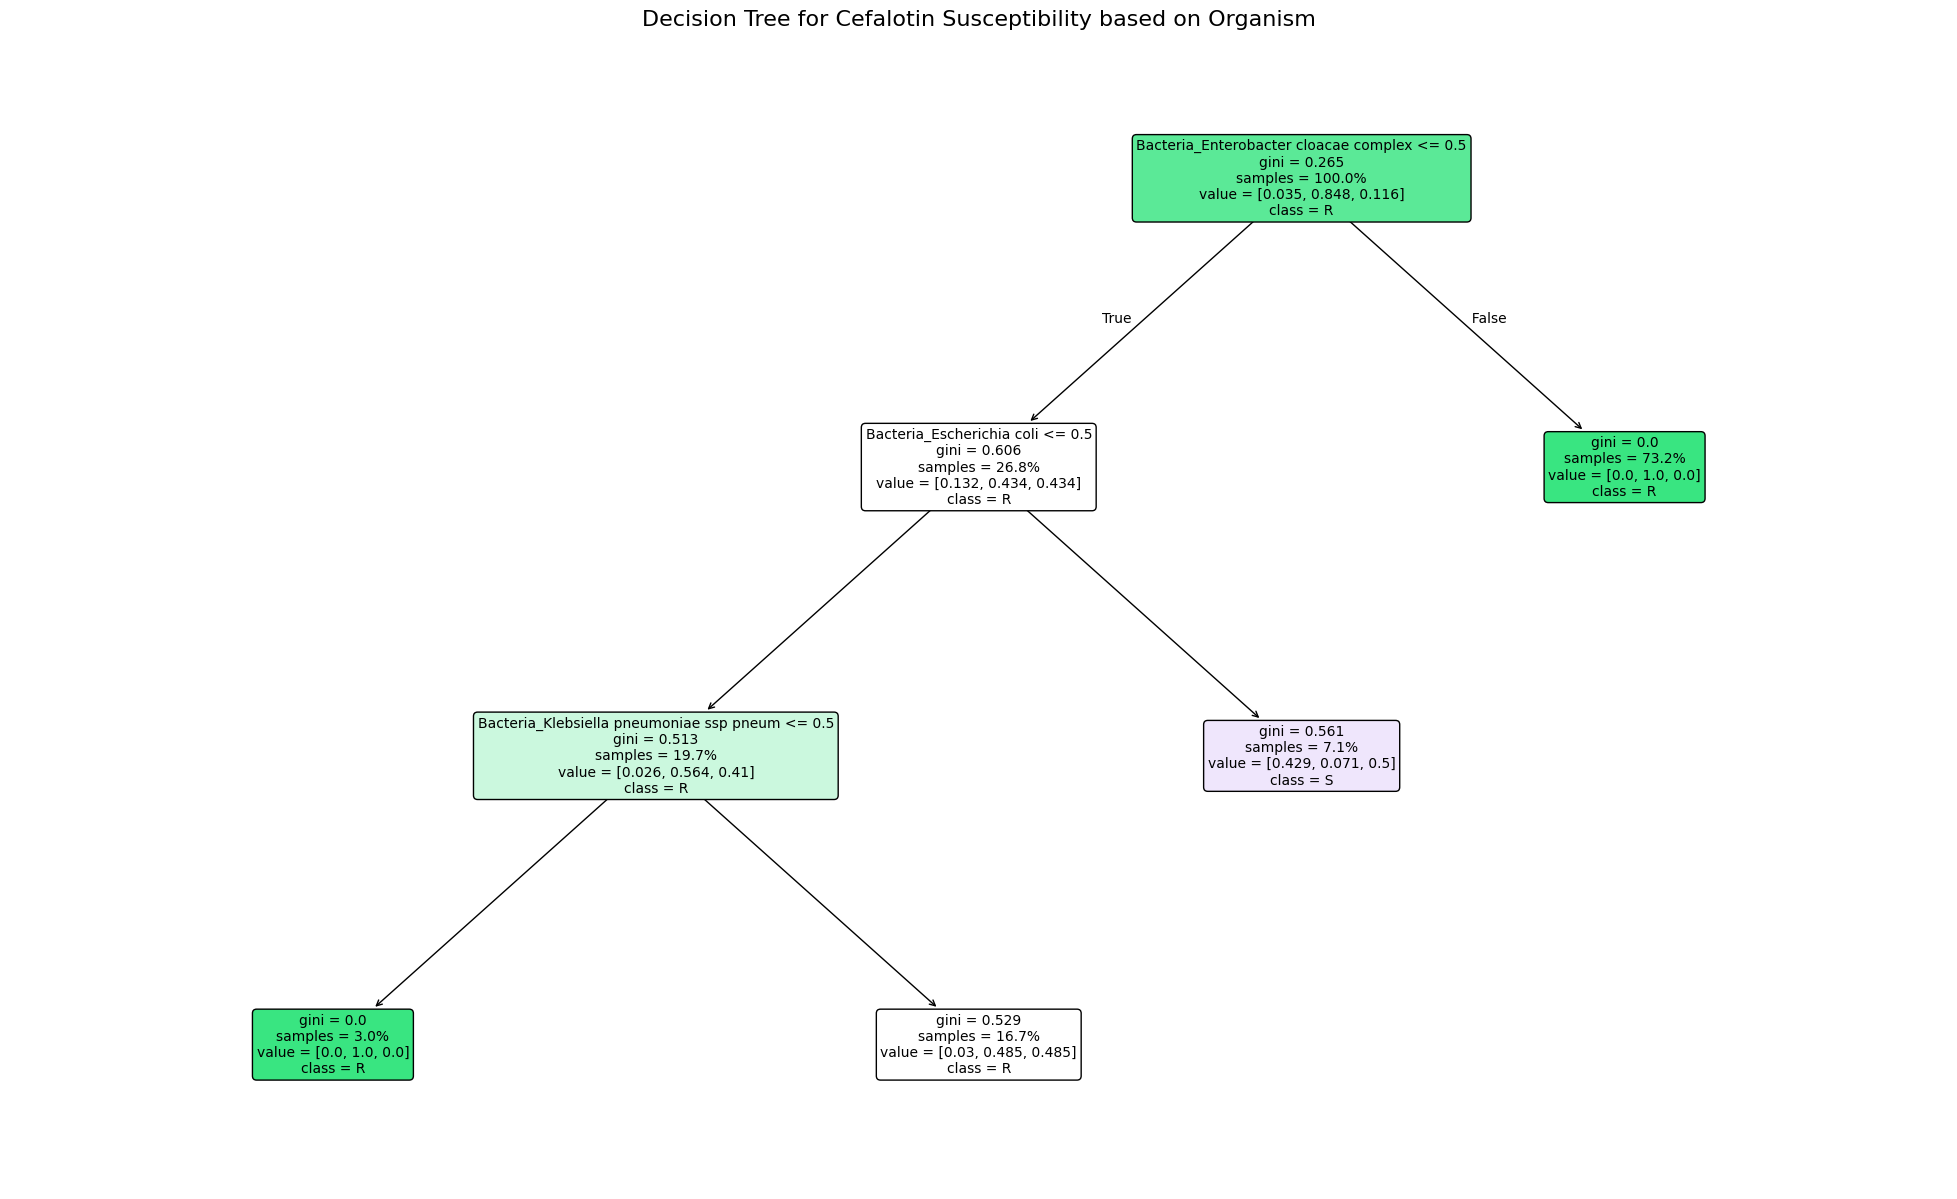

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# --- Configuration ---
TARGET_ANTIBIOTIC = 'Cefalotin'
df = pd.read_excel(r'C:\Users\User\Documents\SPVM 2025\AMR_merged_all_samples_ordered.xlsx')

# 2. Data Cleaning and Preparation
# Clean up column names (remove newlines, replace spaces/slashes/parentheses with underscore)
df.columns = df.columns.str.replace(r'[\n\r]+', ' ', regex=True)
df.columns = df.columns.str.replace(r'[ /()]', '_', regex=True).str.replace('__', '_', regex=False).str.strip('_')

# Identify the target column dynamically after cleaning
target_col_search = TARGET_ANTIBIOTIC.replace(' ', '_').replace('/', '_')
cipro_cols = [col for col in df.columns if target_col_search in col]

if not cipro_cols:
    print(f"Error: Could not find a suitable column for {TARGET_ANTIBIOTIC}.")
    print(f"Available columns: {df.columns.tolist()}")
    exit()

target_col_clean = cipro_cols[0]

y = df[target_col_clean].copy()
X = df[['Bacteria']].copy()

# Remove rows where the target result is not standard (R, S, I)
valid_results = ['R', 'S', 'I']
df_clean = df[y.isin(valid_results)].copy()
X = df_clean[['Bacteria']]
y = df_clean[target_col_clean]

# Encode the categorical target variable (y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_ # R, S, I

# One-hot encode the 'Bacteria' feature
X_encoded = pd.get_dummies(X, columns=['Bacteria'], prefix='Bacteria')

# 3. Train the Decision Tree Model
# Using the entire cleaned dataset for a representative model of the dataset structure
model = DecisionTreeClassifier(max_depth=4, random_state=42) # Max depth limited for clear visualization
model.fit(X_encoded, y_encoded)

# 4. Plot and Save the Decision Tree
feature_names = X_encoded.columns.tolist()

# Prepare class names for the plot based on the LabelEncoder mapping
# 0: I, 1: R, 2: S (or whatever the alphabetical order is for the classes)
class_map = {val: name for val, name in zip(le.transform(le.classes_), le.classes_)}
class_names_for_plot = [f"{class_map[i]}" for i in sorted(class_map.keys())]

plt.figure(figsize=(25, 15))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=class_names_for_plot,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=10
)
plt.title(f"Decision Tree for {TARGET_ANTIBIOTIC} Susceptibility based on Organism", fontsize=16)

# Save the plot
plt.savefig("decision_tree_ciprofloxacin_resistance.png")

print(f"Decision Tree for {TARGET_ANTIBIOTIC} trained and saved to 'decision_tree_ciprofloxacin_resistance.png'")
print(f"Class Mapping (Predicted Class): {class_map}")